# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

In [1]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [ ]:
df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


✍️ **Comentario**: 
 - Hay un total de 40,000 entradas y no se observa ninguna columna con valores nulos o ausentes.
 - La columna date es tipo objet y debería ser tipo datetime

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [5]:
df['user_id'].duplicated().sum()

0

 **Variable `date`**  
Explorar rango de fechas

In [6]:
# Resumen estadístico
df["date"].describe()

count          40000
unique            28
top       2026-01-24
freq            1512
Name: date, dtype: object

In [7]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01
Fecha máxima: 2026-01-28


**Variable `gasto` (numérica)**

In [8]:
# Resumen estadístico
df['gasto'].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [9]:
# Resumen estadístico de usuarios que se convirtieron

convertidos = df[df['converted'] == 1]

print("= RESUMEN DE USUARIOS CONVERTIDOS =")
print(f"Total convertidos: {len(convertidos)}")

print("\n--- Por región ---")
print(convertidos['region'].value_counts())

print("\n--- Por dispositivo ---")
print(convertidos['dispositivo'].value_counts())

print("\n--- Por canal de llegada ---")
print(convertidos['traffic_source'].value_counts())

print("\n--- Por tipo de usuario ---")
print(convertidos['user_type'].value_counts())

print('\nConteos de conversión:')
print(df['converted'].value_counts())
print('\n Porcentajes de conversión:')
print(df['converted'].value_counts(normalize=True) * 100)
print(f"\nGasto promedio por persona: ${convertidos['gasto'].mean():,.3f}")

= RESUMEN DE USUARIOS CONVERTIDOS =
Total convertidos: 5706

--- Por región ---
Norte        1633
Centro       1396
Sur          1112
Occidente     910
Oriente       655
Name: region, dtype: int64

--- Por dispositivo ---
Mobile     3263
Desktop    2443
Name: dispositivo, dtype: int64

--- Por canal de llegada ---
Organic     2480
Ads         1759
Email        918
Referral     549
Name: traffic_source, dtype: int64

--- Por tipo de usuario ---
Nuevo         3738
Recurrente    1968
Name: user_type, dtype: int64

Conteos de conversión:
0    34294
1     5706
Name: converted, dtype: int64

 Porcentajes de conversión:
0    85.735
1    14.265
Name: converted, dtype: float64

Gasto promedio por persona: $65.374


 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [10]:
# Explorar variables categóricas y cómo se distribuyen
def conteo_categoricas (df, columnas):
    for col in columnas:
        print(f"\n=== DISTRIBUCIÓN DE {col.upper()} ===")
            # conteos absolutos
        counts = df[col].value_counts()
        print(counts)
            # porcentajes
        porcentajes = df[col].value_counts(normalize=True) * 100
        print("\nEn porcentajes:")
        for categoria, porcentaje in porcentajes.items():
            print(f"{categoria}: {porcentaje:.2f}%")
    return df
    
columnas_categoricas=['landing', 'region', 'dispositivo', 'traffic_source', 'user_type']
df= conteo_categoricas(df, columnas_categoricas)
    


=== DISTRIBUCIÓN DE LANDING ===
B    20018
A    19982
Name: landing, dtype: int64

En porcentajes:
B: 50.04%
A: 49.95%

=== DISTRIBUCIÓN DE REGION ===
Norte        11166
Centro        9613
Sur           8039
Occidente     6398
Oriente       4784
Name: region, dtype: int64

En porcentajes:
Norte: 27.91%
Centro: 24.03%
Sur: 20.10%
Occidente: 16.00%
Oriente: 11.96%

=== DISTRIBUCIÓN DE DISPOSITIVO ===
Mobile     24829
Desktop    15171
Name: dispositivo, dtype: int64

En porcentajes:
Mobile: 62.07%
Desktop: 37.93%

=== DISTRIBUCIÓN DE TRAFFIC_SOURCE ===
Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: traffic_source, dtype: int64

En porcentajes:
Organic: 44.97%
Ads: 29.84%
Email: 15.31%
Referral: 9.89%

=== DISTRIBUCIÓN DE USER_TYPE ===
Nuevo         26033
Recurrente    13967
Name: user_type, dtype: int64

En porcentajes:
Nuevo: 65.08%
Recurrente: 34.92%


## 💰 Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [11]:
# Gasto por versión
gasto_A = df[(df['landing']=='A')&(df['converted']==1)]['gasto']
gasto_B = df[(df['landing']=='B')&(df['converted']==1)]['gasto']

# Verificar cantidad de datos que tiene cada grupo
print(f"Cantidad de datos pagina A:{len(gasto_A)}")
print(f"Cantidad de datos pagina A:{len(gasto_B)}")
print(f"Gasto promedio por usuario página A: {gasto_A.mean(): .2f}")
print(f"Gasto promedio por usuario página B: {gasto_B.mean(): .2f}")

Cantidad de datos pagina A:2512
Cantidad de datos pagina A:3194
Gasto promedio por usuario página A:  61.09
Gasto promedio por usuario página B:  68.75


In [12]:
from scipy.stats import ttest_ind

### Prueba ... T de Student

**Hipótesis:** 
- **Hipótesis nula (H₀):** ... El gasto promedio de los clientes es igual en la página A y en la página B.
- **Hipótesis alternativa (H₁):** ... El gasto promedio de los clientes es diferente en la página A y en la página B.

In [ ]:
tstat, p_value = ttest_ind(gasto_A, gasto_B)

# Visualizar resultados
print(f"Estadístico : {tstat}")
print(f"Valor p: {p_value}")

Estadístico : -9.36563589591332
Valor p: 1.0635288333792346e-20


### 📝 Conclusión e interpretación

**Decisión:**  
(¿Se rechaza o no la hipótesis nula?)
Rechazamos la hipótesis nula

**Interpretación de negocio:**  
Explica con tus propias palabras qué indican estos resultados sobre el gasto promedio entre la página A y la página B:

Esto significa que existe una diferencia estadística significativa entre el gasto en la versión A de la págna y el gasto  en la versión B de la página mostrada al usuario, de acuerdo con el estadístico t siendo el gasto mayor en la versión B .

---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen difere]ncias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba ... Z para comparar proporciones

**Hipótesis:**
- **Hipótesis nula (H₀):** ... La tasa de conversión es igual en ambas páginas. Cualquier diferencia se debe al azar del muestreo.
- **Hipótesis alternativa (H₁):** ... La tasa de conversión es diferente entre ambas páginas. Hay un factor que influye en la desición de compra.

In [14]:
# Número de usuarios convertidos por página
conversiones = df.groupby('landing')['converted'].sum()
conversiones
# Total de usuarios por página
totales=df.groupby('landing')['converted'].count()
totales
print("Usuarios convertidos por página:\n", conversiones)
print("\nTotal de usuarios por página:\n", totales)


Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
Name: converted, dtype: int64


In [15]:
exitos=[conversiones['A'], conversiones['B']]
print(exitos)
observaciones=[totales['A'], totales['B']]
print(observaciones)

[2512, 3194]
[19982, 20018]


In [16]:
from statsmodels.stats.proportion import proportions_ztest

In [17]:
# Aplicar prueba
z_stat, p_value = proportions_ztest(exitos, observaciones)


# Visualizar resultados
print(f"Estadístico : {z_stat}")
print(f"Valor p: {p_value}")

Estadístico : -9.677362674655983
Valor p: 3.7629765627523803e-22


In [18]:
tasa_A= exitos[0] / observaciones [0]
print(f" tasa de conversión página A: {tasa_A: .2%}")
tasa_B= exitos[1] / observaciones [1]
print(f" tasa de conversión página B: {tasa_B: .2%}")

 tasa de conversión página A:  12.57%
 tasa de conversión página B:  15.96%


### 📝 Conclusión e interpretación

**Decisión:**  
(¿Se rechaza o no la hipótesis nula?)

Rechazamos la hipótesis nula

**Interpretación de negocio:**  
Explica qué indica el resultado sobre la tasa de conversión entre la página A y la página B:

Existe evidencia de una diferencia estadística significativa entre las tasas de conversión, siendo la página B la que tiene una mayor tasa de conversión.


## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba ... Chi-cuadrada

**Hipótesis:**
- **Hipótesis nula (H₀):** ... No existe relación entre las dos variables (son independientes)
  
- **Hipótesis alternativa (H₁):** ... Existe relación entre las dos variables (son dependientes)

In [19]:
from scipy.stats import chi2_contingency
tabla = pd.crosstab(df['traffic_source'], df['converted'])
tabla

converted,0,1
traffic_source,,
Ads,10176,1759
Email,5205,918
Organic,15507,2480
Referral,3406,549


In [20]:
# Aplicar prueba
chi2_stat, p_valuex2, dof, expected = chi2_contingency(tabla)
print(f"Estadístico chi cuadrado: {chi2_stat: .3f}")
print(f"Valor P: {p_valuex2: .3f}")
print(f"Grados de libertad: {dof}")
print("\n Frecuencias esperadas:")
print(expected)

alpha = 0.05
if p_valuex2 < alpha:
    print('Rechazamos la hipótesis nula: hay evidencia de asociación')
else:
    print('No rechazamos la hipótesis nula: no hay evidencia de asociación')


Estadístico chi cuadrado:  8.662
Valor P:  0.034
Grados de libertad: 3

 Frecuencias esperadas:
[[10232.47225  1702.52775]
 [ 5249.55405   873.44595]
 [15421.15445  2565.84555]
 [ 3390.81925   564.18075]]
Rechazamos la hipótesis nula: hay evidencia de asociación


In [21]:
tabla_normalizada = pd.crosstab(df['traffic_source'], df['converted'], normalize='index') * 100
print("Tasas de conversión por fuente de tráfico:")
print(tabla_normalizada[1].round(2))  # Solo la columna de convertidos

Tasas de conversión por fuente de tráfico:
traffic_source
Ads         14.74
Email       14.99
Organic     13.79
Referral    13.88
Name: 1, dtype: float64


### 📝 Conclusión e interpretación

**Decisión:**  
(¿Se rechaza o no la hipótesis nula?)

Rechazamos la hipótesis nula

**Interpretación de negocio:**  
Explica qué indican los resultados considerando tanto las cantidades absolutas como las tasas de conversión.
Email tiene una mayor tasa de conversión, seguida de Ads en segundo lugar, Referral en tercero seguido de Organic en 4to, aunque esta última tiene una mayor cantidad de tráfico y un valor absoluto de conversión alto.

## 👤 Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba ... Fisher

**Hipótesis:**
- **Hipótesis nula (H₀):** ... No hay asociación significativa entre las variables
  
- **Hipótesis alternativa (H₁):** ... Hay una asociación significativa entre las variables.

In [ ]:
tabla2 = pd.crosstab(df['user_type'], df['converted'])
tabla2

converted,0,1
user_type,,
Nuevo,22295,3738
Recurrente,11999,1968


In [ ]:
from scipy.stats import fisher_exact
tabla3 = pd.crosstab(df['user_type'], df['converted'])
tabla3

converted,0,1
user_type,,
Nuevo,22295,3738
Recurrente,11999,1968


In [ ]:
# Aplicar prueba
odds_ratio, p_value3 = fisher_exact(tabla3)
print(f"Resultados de la prueba exacta de Fisher:")
print(f"Odds Ratio:{odds_ratio: .3f}")
print (f"Valor P:{p_value3: .3f} ")

alpha=0.05
if p_value3 < alpha:
    print("Hay asociación significativa entre las variables")
else:
    print("No hay evidencia de asociación significativa")


Resultados de la prueba exacta de Fisher:
Odds Ratio: 0.978
Valor P: 0.472 
No hay evidencia de asociación significativa


### 📝 Conclusión e interpretación

**Decisión:**  
(¿Se rechaza o no la hipótesis nula?)
No se rechaza la hipótesis nula

**Interpretación de negocio:**  
Explica qué indica el resultado.
No existe evidencia estadística de asociación entre el tipo de usuario y la conversión.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

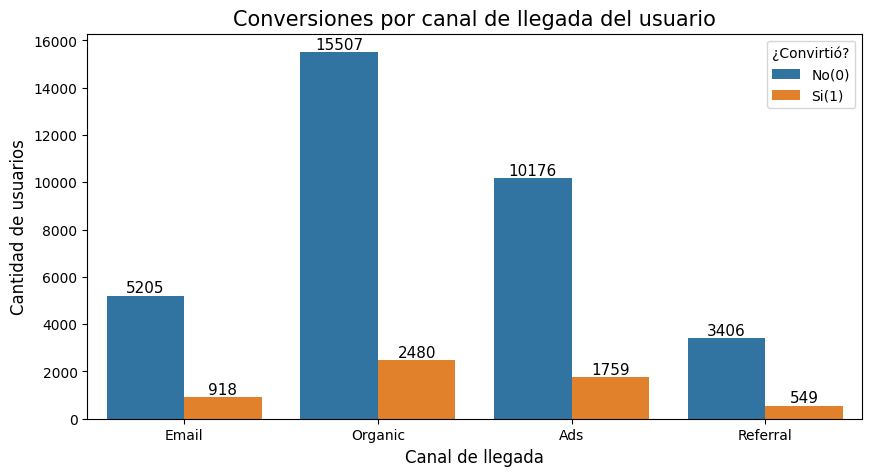

In [25]:
plt.figure(figsize=(10,5))
ax=sns.countplot(data=df, x='traffic_source', hue='converted')

for bar in ax.patches:
    height=bar.get_height()
    ax.text(x=bar.get_x()+bar.get_width()/2,
    y=height,
    s=height,
    ha='center',
    va='bottom',
    fontsize=11)
plt.title('Conversiones por canal de llegada del usuario', fontsize=15)
plt.xlabel('Canal de llegada', fontsize=12)
plt.ylabel('Cantidad de usuarios', fontsize=12)
plt.legend(title='¿Convirtió?', labels=['No(0)','Si(1)'])
plt.show()

✍️ **Comentario**: 

Observamos que el canal Organic es quien tiene un mayor tráfico de usuarios, además de una cantidad mayor de usuarios que convierten, y siendo Referral el canal que tiene un menor tráfico de usuarios y de personas que convierten.

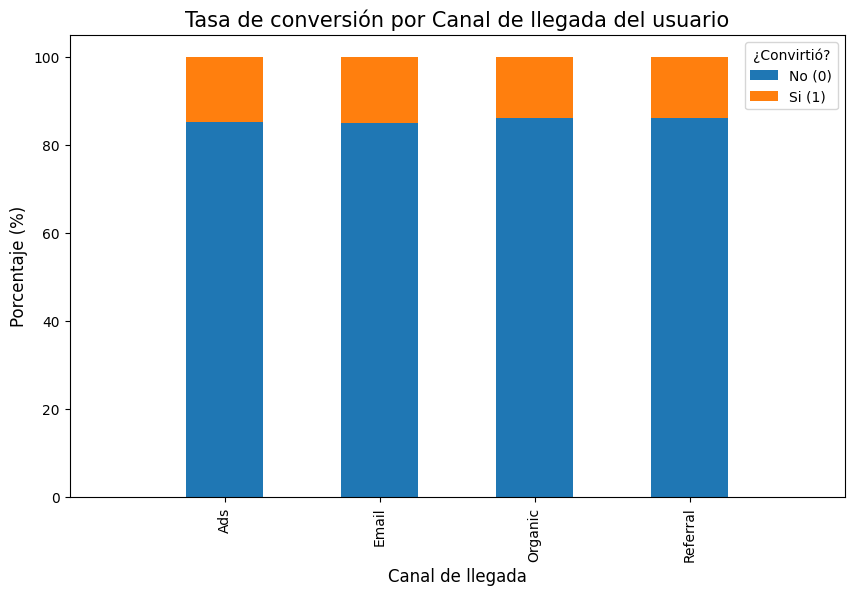

In [26]:
tabla4=pd.crosstab(df['traffic_source'], df['converted'], normalize='index')*100

ax=tabla4.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Tasa de conversión por Canal de llegada del usuario', fontsize=15)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xlabel('Canal de llegada', fontsize=12)
ax.set_xlim(-1,4)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Si (1)'], loc='upper right')
plt.show()

✍️ **Comentario**: 

Observamos las tasas de conversión de cada canal donde se observa que todos los canales tienen una tasa de conversión muy similar, no se observa una diferencia a simple vista.

### Relación entre el tipo de usuario y la conversión

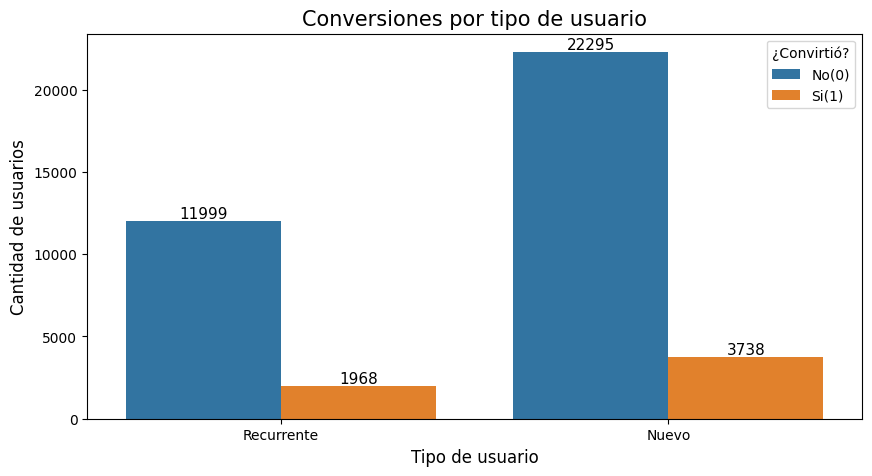

In [27]:
plt.figure(figsize=(10,5))
ax=sns.countplot(data=df, x='user_type', hue='converted')

for bar in ax.patches:
    height=bar.get_height()
    ax.text(x=bar.get_x()+bar.get_width()/2,
    y=height,
    s=height,
    ha='center',
    va='bottom',
    fontsize=11)
plt.title('Conversiones por tipo de usuario', fontsize=15)
plt.xlabel('Tipo de usuario', fontsize=12)
plt.ylabel('Cantidad de usuarios', fontsize=12)
plt.legend(title='¿Convirtió?', labels=['No(0)','Si(1)'])
plt.show()

✍️ **Comentario**: 

Observamos una mayor cantidad de personas que son usuarios nuevos practicamente el doble en comparación con los usuarios recurrentes, esto se observa en la cantidad de los que convierten como en los que no convierten.

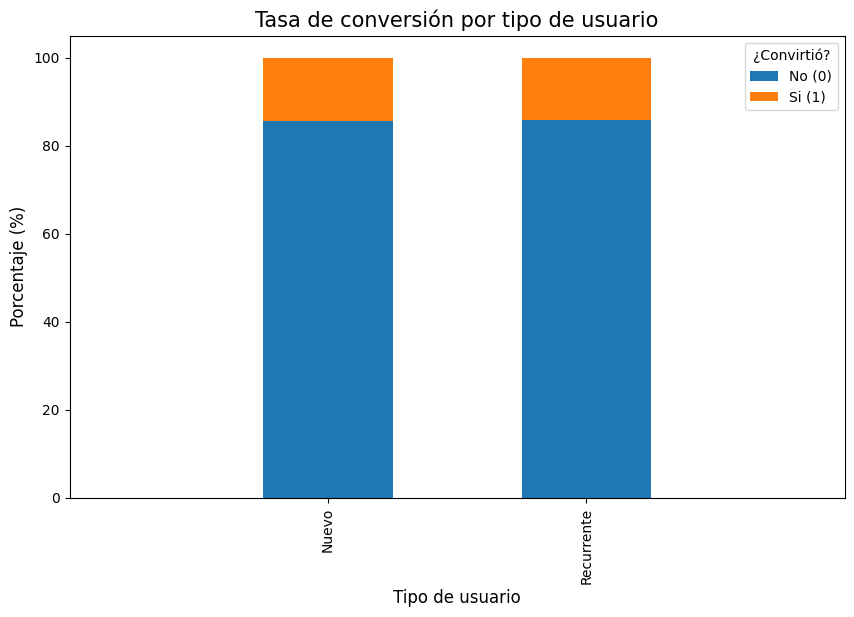

In [28]:
tabla5=pd.crosstab(df['user_type'], df['converted'], normalize='index')*100

ax=tabla5.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Tasa de conversión por tipo de usuario', fontsize=15)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xlabel('Tipo de usuario', fontsize=12)
ax.set_xlim(-1,2)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Si (1)'], loc='upper right')
plt.show()

✍️ **Comentario**: 

La tasa de conversión por tipo de usuario se observa prácticamente igual, consistente con el p-value obtenido por la prueba de Fisher

## 🧩  Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?


---

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**
- Gasto promedio por usuario que convirtió página A:  61.09
- Gasto promedio por usuario que convirtió página B:  68.75
- **Interpretación:**
La págia B tiene un promedio mayor de conversión, esto es consistente con el número de conversiones mayor que se produce en la página B que es de 3194 en comparación con la página A que es de 2512

**Tasa de conversión:** 
- Tasa de conversión página A:  12.57%
- Tasa de conversión página B:  15.96%
- **Interpretación:**
La tasa de conversión mayor en la página B es diferente estadísticamente con un nivel de confianza del 95%, es consistente con el mayor gasto promedio y la cantidad de conversiones
---

#### 📊 **Segmentación por fuente de tráfico**
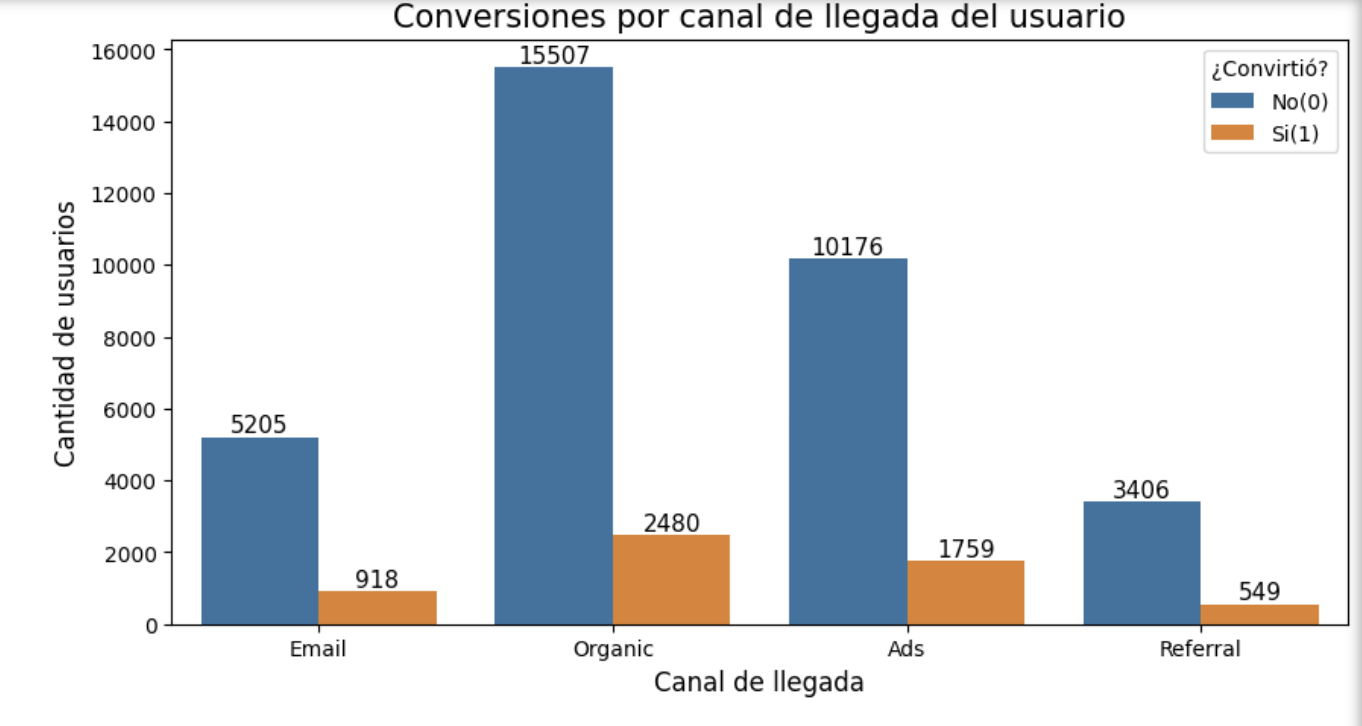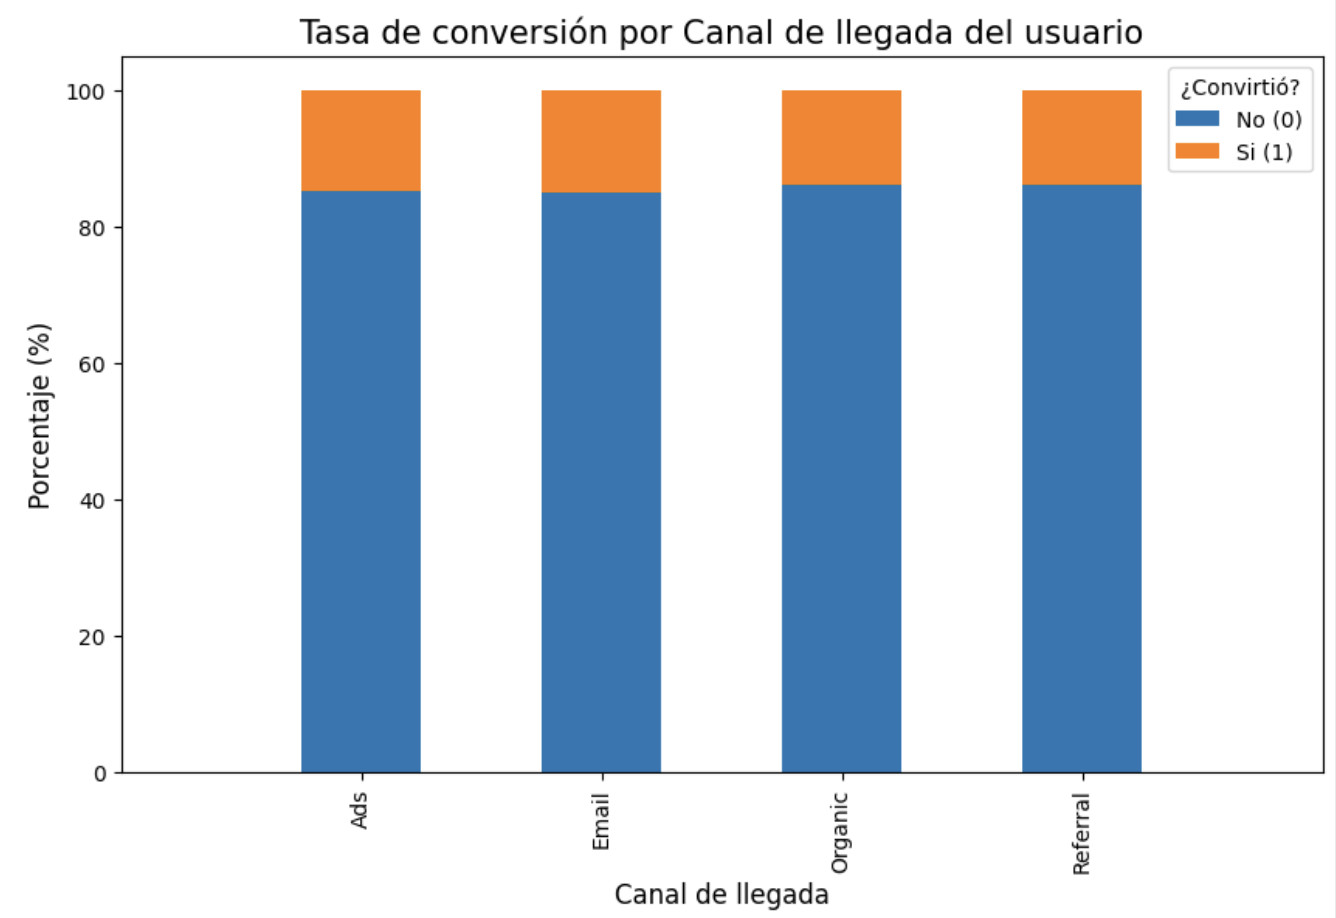
- **Interpretación:**
 En el gráfico podemos observar que Organic es quien tiene un mayor tráfico de usuarios, además de una cantidad mayor de usuarios que convierten pero observando la segunda gráfica nos damos cuenta que las tasas de conversión son muy similares en todos los canales de llegada y diferente a lo que se observa a simple vista Email tiene una mayor tasa de conversión.
La estadística nos dice que fuente de tráfico y conversión tienen una asociación estadísticamente significativa.

 ---

#### 📊 **Segmentación por tipo de usuario**
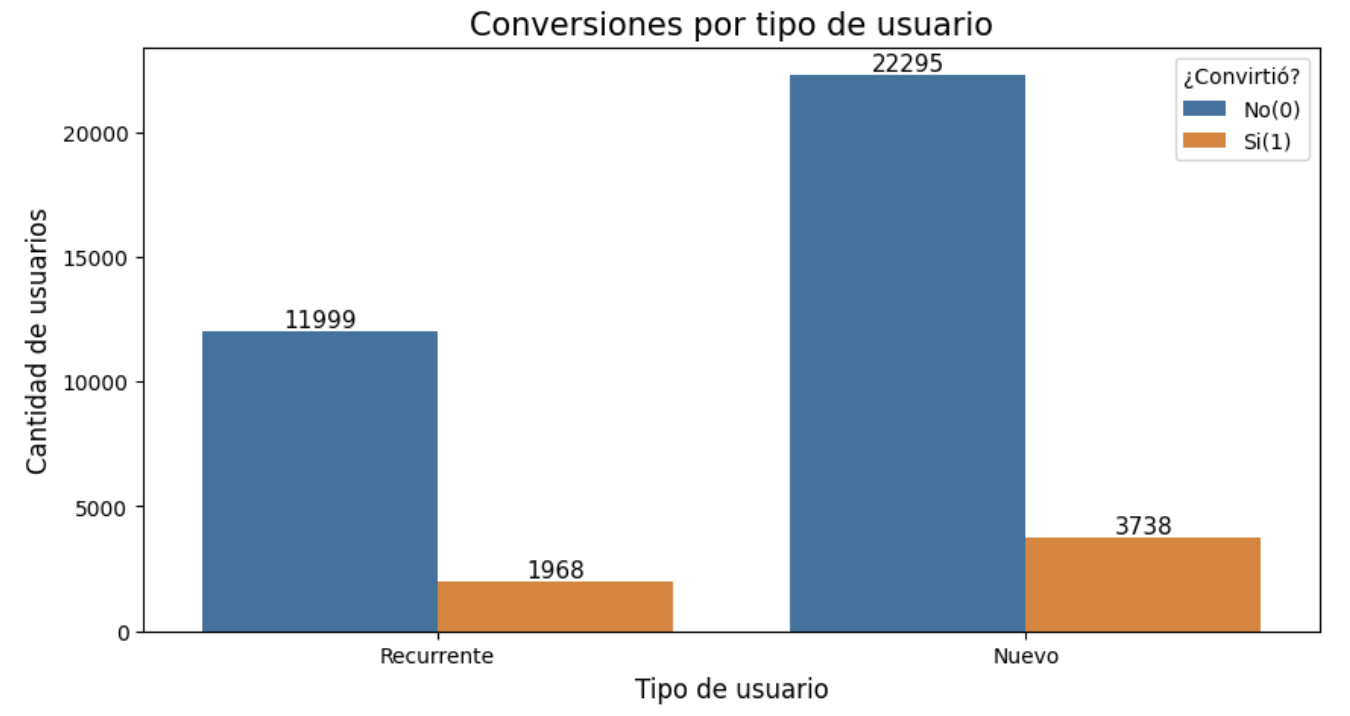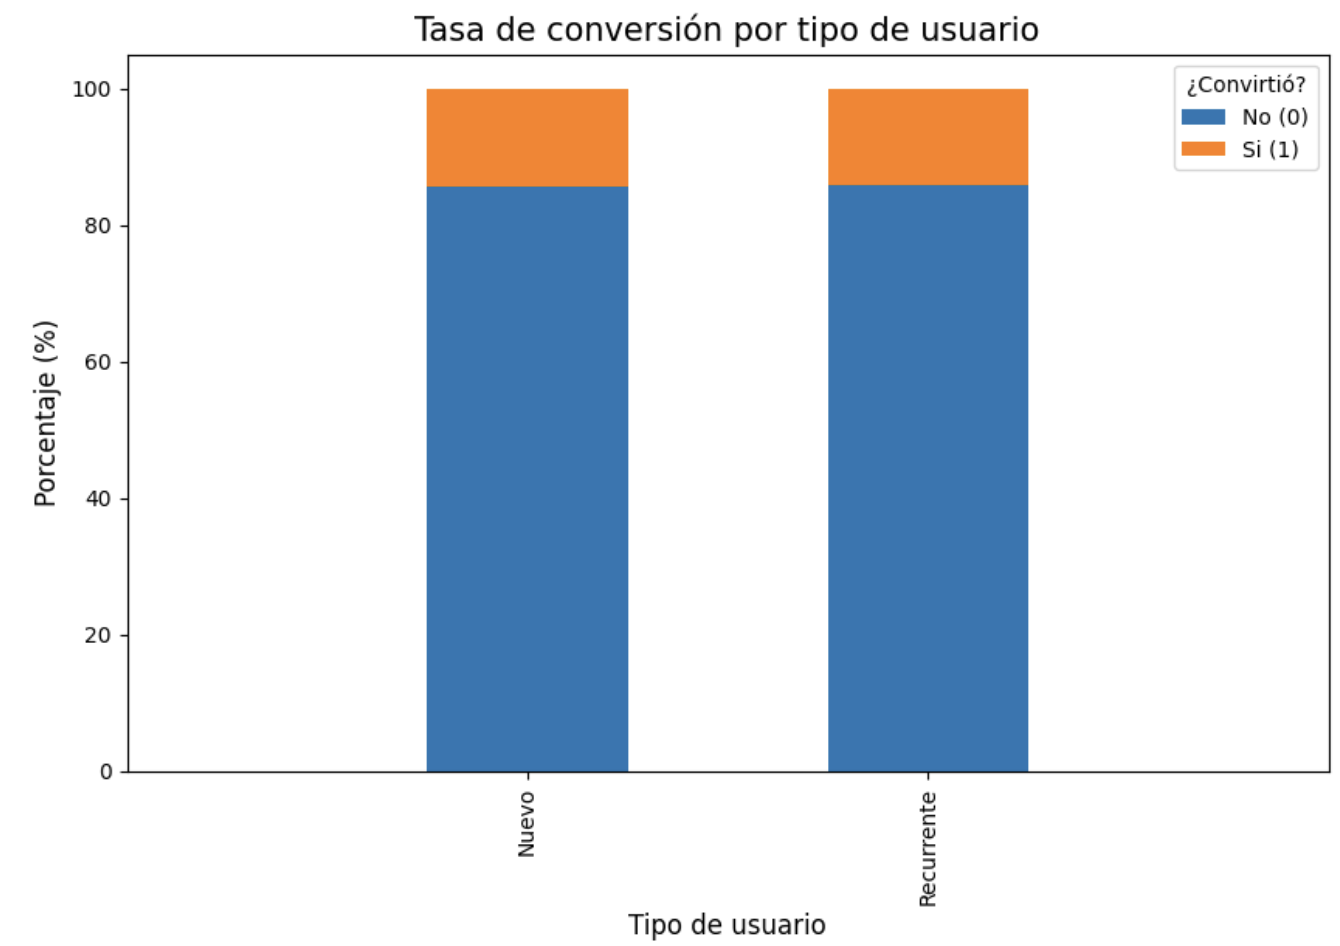
- **Interpretación:**
En el primer gráfico se observa de primera instancia que lo usuarios nuevos son mas, casi el dolbe de los usuarios recurrentes tanto los que convierten como los que no convierten, el segundo gráfico nos muestra que el porcentaje de conversión entre los usuarios nuevos como los recurrentes es prácticamente el mismo, esto se confirma con la prueba de Fisher que nos dice que no existe una relación entre el tipo de usuario y la conversión por lo tanto que un usuario sea recurrente no significa que compre mas.
---

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---

#### 💡 **Recomendaciones de negocio:** 

- Recomendaría revisar el porqué la página B está teniendo una mejor tasa de conversión y en su caso utilizar esta versión definitivamente.
- Poner especial atención al canal Email debido a que tiene una mayor conversión que los demás, tal vez si aumenta el tráfico en este canal las ventas aumenten.
- De igual manera poder mejorar la conversión de Organic, teniendo tanta gente ver la manera de mejorar ese porcentaje de conversión.
- Ver la manera de retener a los usuarios nuevos, tener en cuenta porqué están llegando en esa cantidad y retener la mayor cantidad posible para que se vuelvan recurrentes y si es posible mejorar esa tasa de conversión.

<div class="alert alert-block alert-success">
<b>Aspectos positivos del proyecto</b> <a class="tocSkip"></a><br />

- Las observaciones intermedias, así como las conclusiones finales me parecen bastante detalladas
- Las graficas utilizadas me parecen del tipo correcto
- El proyecto esta ordenado
    
</div> 
